# Thesis Evaluation Results Dashboard
Visualises Stage 1 and Stage 2 ablation results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

ROOT = Path(".")

s1 = pd.read_csv(ROOT / "stage1_results" / "stage1_results.csv")
s2 = pd.read_csv(ROOT / "stage2_results" / "stage2_results.csv")

s2 = s2[s2["error"].isna() | (s2["error"] == "")].copy()
s2["dhr_pct"] = s2["dhr_mean"] * 100

VARIANT_LABELS = {
    "V_full":    "Full pipeline",
    "V_no_rag":  "No RAG",
    "V_no_chat": "No chat",
    "V_no_iter": "No iterations",
}
LOG_LABELS    = {"bpic2017": "BPIC 2017", "bpic2012": "BPIC 2012", "sepsis": "Sepsis"}
VARIANT_ORDER = ["V_full", "V_no_rag", "V_no_chat", "V_no_iter"]
LOG_ORDER     = ["bpic2017", "bpic2012", "sepsis"]
COLORS        = ["#2563eb", "#f59e0b", "#10b981", "#ef4444"]

s2[["variant","log","dhr_pct","mki_mean","nis_mean","best_iter_score","n_iterations","attempts"]]

,variant,log,dhr_pct,mki_mean,nis_mean,best_iter_score,n_iterations,attempts
0,V_full,bpic2017,80.00,-19.53,16.91,113.665,4,8
1,V_no_rag,bpic2017,60.00,-30.80,2.37,88.255,4,10
2,V_no_chat,bpic2017,80.00,-21.64,13.57,69.545,4,11
3,V_no_iter,bpic2017,80.00,-13.43,9.94,46.282,1,2
4,V_full,bpic2012,75.00,-32.45,24.09,187.450,2,5
5,V_no_rag,bpic2012,100.00,-26.36,26.37,142.100,1,2
6,V_no_chat,bpic2012,100.00,-35.19,40.04,126.098,4,9
7,V_no_iter,bpic2012,75.00,-50.16,37.17,168.900,1,2
8,V_full,sepsis,66.67,-1.06,0.58,0.712,4,8
9,V_no_rag,sepsis,100.00,-1.41,1.41,0.535,4,8


## Figure 1 — Prospect-Theory Score (primary ranking metric)

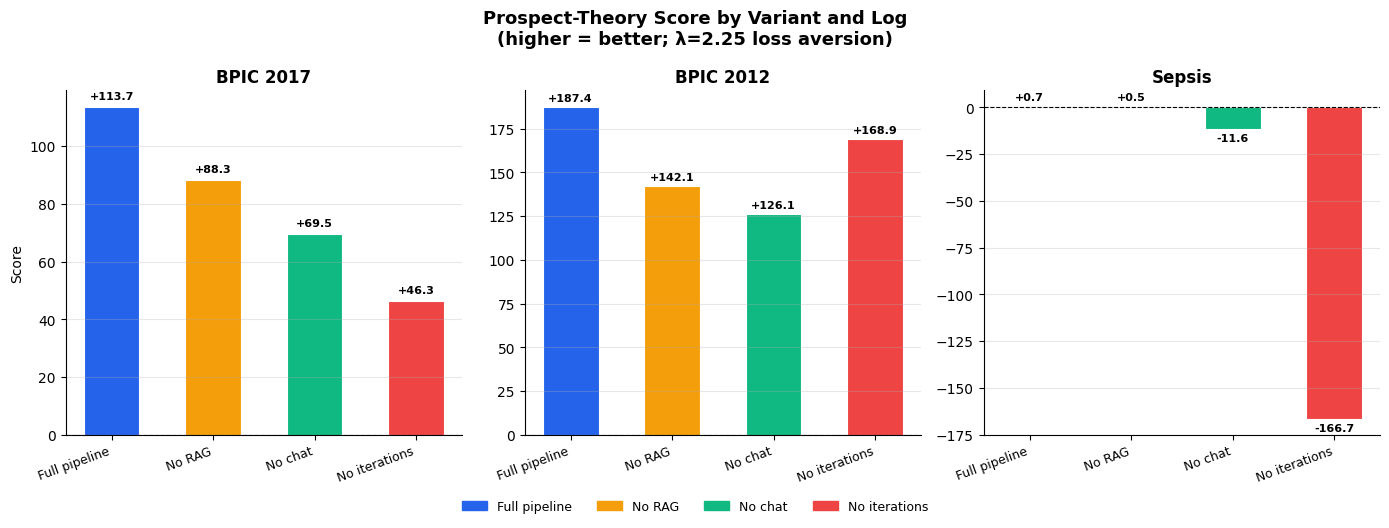

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle("Prospect-Theory Score by Variant and Log\n(higher = better; λ=2.25 loss aversion)",
             fontsize=13, fontweight="bold")

x     = np.arange(len(VARIANT_ORDER))
width = 0.55

for ax, log in zip(axes, LOG_ORDER):
    subset = s2[s2["log"] == log].set_index("variant")
    scores = [subset.loc[v, "best_iter_score"] if v in subset.index else 0 for v in VARIANT_ORDER]
    bars   = ax.bar(x, scores, width, color=COLORS, edgecolor="white", linewidth=0.8)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(LOG_LABELS[log], fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, score in zip(bars, scores):
        va     = "bottom" if score >= 0 else "top"
        offset = 2 if score >= 0 else -2
        ax.text(bar.get_x() + bar.get_width()/2, score + offset,
                f"{score:+.1f}", ha="center", va=va, fontsize=8, fontweight="bold")

patches = [mpatches.Patch(color=COLORS[i], label=VARIANT_LABELS[v]) for i, v in enumerate(VARIANT_ORDER)]
fig.legend(handles=patches, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Figure 2 — KPI Directional Hit Rate (DHR)

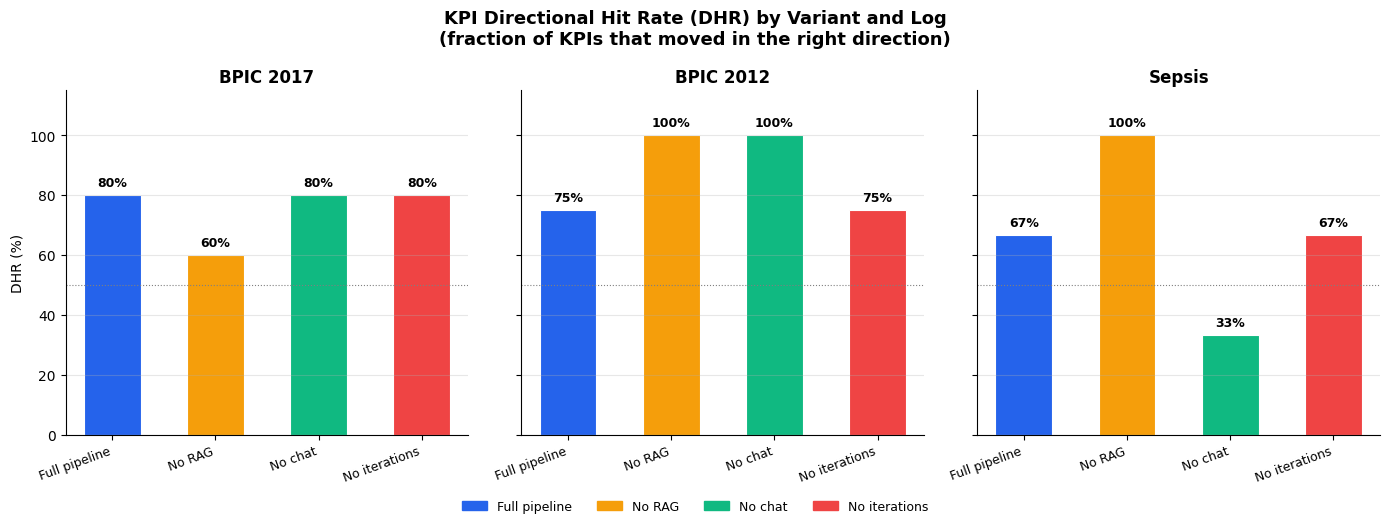

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle("KPI Directional Hit Rate (DHR) by Variant and Log\n(fraction of KPIs that moved in the right direction)",
             fontsize=13, fontweight="bold")

for ax, log in zip(axes, LOG_ORDER):
    subset = s2[s2["log"] == log].set_index("variant")
    dhrs   = [subset.loc[v, "dhr_pct"] if v in subset.index else 0 for v in VARIANT_ORDER]
    bars   = ax.bar(x, dhrs, width, color=COLORS, edgecolor="white", linewidth=0.8)

    ax.axhline(50, color="grey", linewidth=0.8, linestyle=":")
    ax.set_ylim(0, 115)
    ax.set_title(LOG_LABELS[log], fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("DHR (%)" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, val in zip(bars, dhrs):
        ax.text(bar.get_x() + bar.get_width()/2, val + 2,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

patches = [mpatches.Patch(color=COLORS[i], label=VARIANT_LABELS[v]) for i, v in enumerate(VARIANT_ORDER)]
fig.legend(handles=patches, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Figure 3 — Net Improvement Score (NIS)

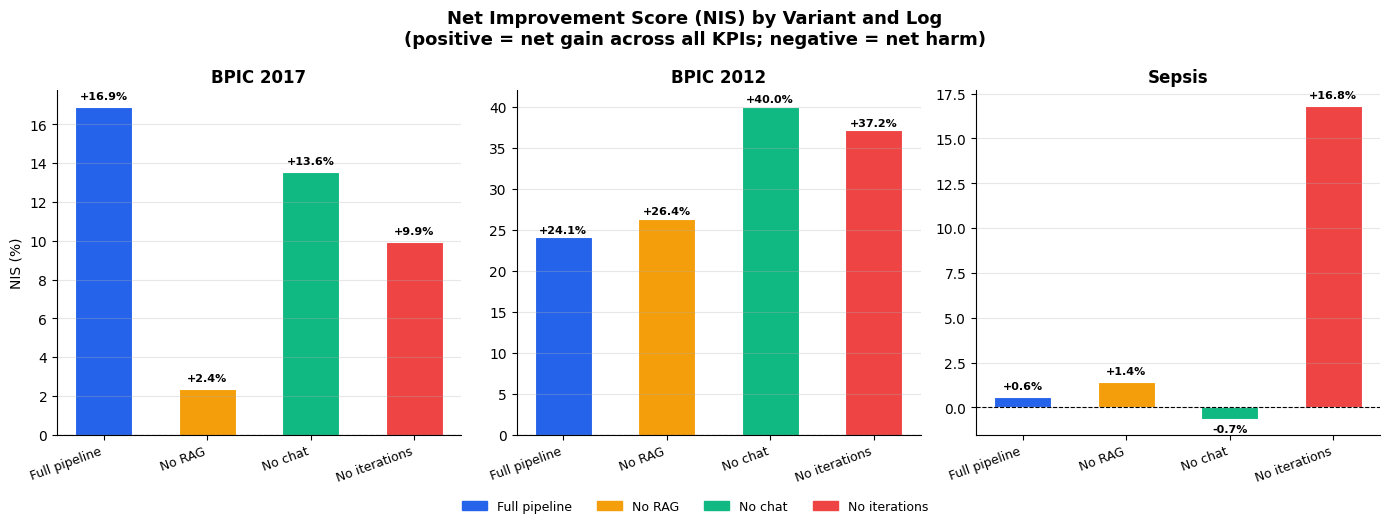

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle("Net Improvement Score (NIS) by Variant and Log\n(positive = net gain across all KPIs; negative = net harm)",
             fontsize=13, fontweight="bold")

for ax, log in zip(axes, LOG_ORDER):
    subset = s2[s2["log"] == log].set_index("variant")
    nis    = [subset.loc[v, "nis_mean"] if v in subset.index else 0 for v in VARIANT_ORDER]
    bars   = ax.bar(x, nis, width, color=COLORS, edgecolor="white", linewidth=0.8)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(LOG_LABELS[log], fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("NIS (%)" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, val in zip(bars, nis):
        va     = "bottom" if val >= 0 else "top"
        offset = 0.3 if val >= 0 else -0.3
        ax.text(bar.get_x() + bar.get_width()/2, val + offset,
                f"{val:+.1f}%", ha="center", va=va, fontsize=8, fontweight="bold")

patches = [mpatches.Patch(color=COLORS[i], label=VARIANT_LABELS[v]) for i, v in enumerate(VARIANT_ORDER)]
fig.legend(handles=patches, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Figure 4 — Full Summary Heatmap

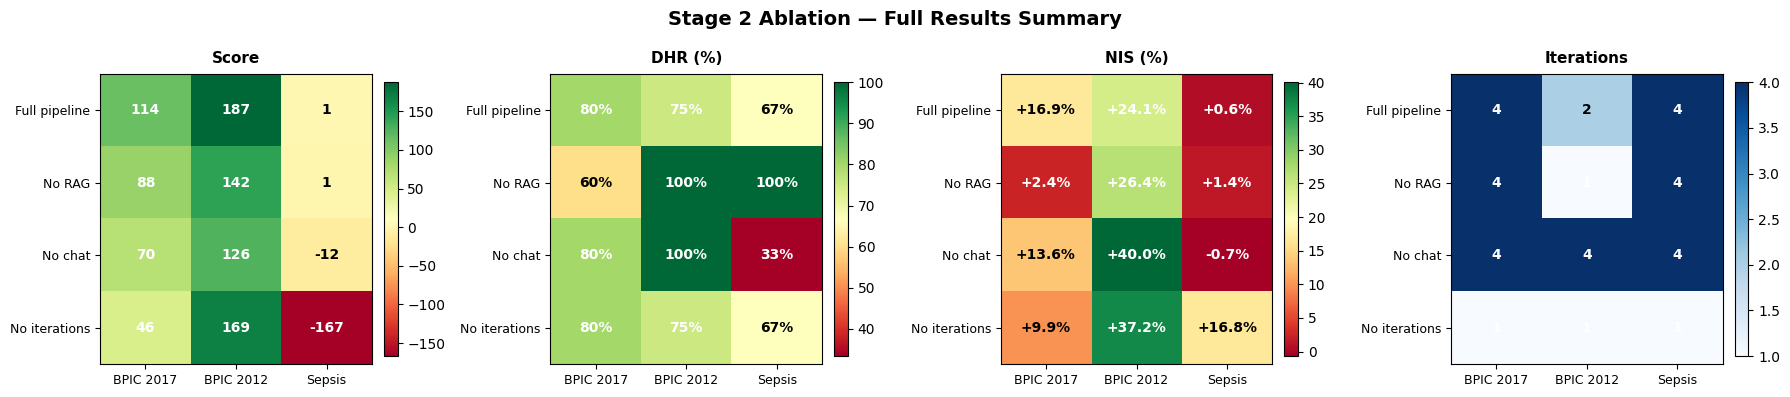

In [ ]:
def make_pivot(metric):
    return s2.pivot(index="variant", columns="log", values=metric).reindex(
        index=VARIANT_ORDER, columns=LOG_ORDER
    )

score_piv = make_pivot("best_iter_score")
dhr_piv   = make_pivot("dhr_pct")
nis_piv   = make_pivot("nis_mean")
iters_piv = make_pivot("n_iterations")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Stage 2 Ablation — Full Results Summary", fontsize=14, fontweight="bold")

configs = [
    (score_piv, "Score",      "RdYlGn", "{:.0f}"),
    (dhr_piv,   "DHR (%)",    "RdYlGn", "{:.0f}%"),
    (nis_piv,   "NIS (%)",    "RdYlGn", "{:+.1f}%"),
    (iters_piv, "Iterations", "Blues",  "{:.0f}"),
]

for ax, (data, title, cmap, fmt) in zip(axes, configs):
    vals = data.values.astype(float)
    im   = ax.imshow(vals, cmap=cmap, aspect="auto")

    ax.set_xticks(range(len(LOG_ORDER)))
    ax.set_xticklabels([LOG_LABELS[l] for l in LOG_ORDER], fontsize=9)
    ax.set_yticks(range(len(VARIANT_ORDER)))
    ax.set_yticklabels([VARIANT_LABELS[v] for v in VARIANT_ORDER], fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)

    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    for i in range(len(VARIANT_ORDER)):
        for j in range(len(LOG_ORDER)):
            val = vals[i, j]
            if np.isnan(val):
                continue
            normed     = (val - vmin) / (vmax - vmin + 1e-9)
            text_color = "white" if normed > 0.6 or normed < 0.2 else "black"
            ax.text(j, i, fmt.format(val), ha="center", va="center",
                    fontsize=10, fontweight="bold", color=text_color)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Figure 5 — Stage 1 Results

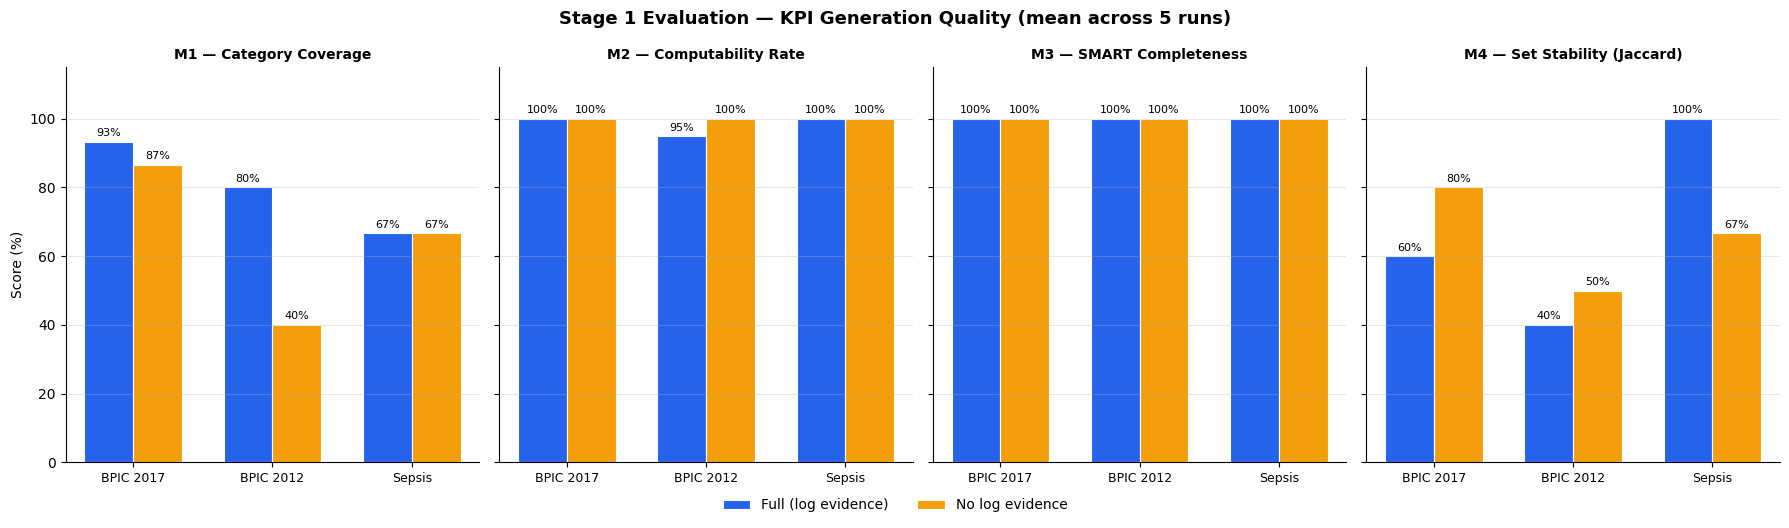

In [ ]:
s1_agg = s1.groupby(["log", "variant"]).agg(
    M1_mean=("category_coverage",  "mean"),
    M2_mean=("computable_rate",    "mean"),
    M3_mean=("smart_complete_rate","mean"),
    M4=("stability", "first"),
).reset_index()

s1_agg["M1_pct"] = s1_agg["M1_mean"] * 100
s1_agg["M2_pct"] = s1_agg["M2_mean"] * 100
s1_agg["M3_pct"] = s1_agg["M3_mean"] * 100
s1_agg["M4_pct"] = s1_agg["M4"]      * 100

VARIANT_COLORS   = {"full": "#2563eb", "no_log": "#f59e0b"}
VARIANT_LABELS_S1 = {"full": "Full (log evidence)", "no_log": "No log evidence"}
metrics       = ["M1_pct", "M2_pct", "M3_pct", "M4_pct"]
metric_labels = [
    "M1 — Category Coverage",
    "M2 — Computability Rate",
    "M3 — SMART Completeness",
    "M4 — Set Stability (Jaccard)",
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle("Stage 1 Evaluation — KPI Generation Quality (mean across 5 runs)",
             fontsize=13, fontweight="bold")

x_s1    = np.arange(len(LOG_ORDER))
w_s1    = 0.35

for ax, metric, mlabel in zip(axes, metrics, metric_labels):
    for i, variant in enumerate(["full", "no_log"]):
        vals = [
            s1_agg.loc[(s1_agg["log"] == log) & (s1_agg["variant"] == variant), metric].values[0]
            if len(s1_agg[(s1_agg["log"] == log) & (s1_agg["variant"] == variant)]) else 0
            for log in LOG_ORDER
        ]
        offset = (i - 0.5) * w_s1
        bars = ax.bar(x_s1 + offset, vals, w_s1,
                      color=VARIANT_COLORS[variant], label=VARIANT_LABELS_S1[variant],
                      edgecolor="white", linewidth=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                    f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

    ax.set_ylim(0, 115)
    ax.set_title(mlabel, fontsize=10, fontweight="bold")
    ax.set_xticks(x_s1)
    ax.set_xticklabels([LOG_LABELS[l] for l in LOG_ORDER], fontsize=9)
    ax.set_ylabel("Score (%)" if ax == axes[0] else "")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05),
           frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

## Table — Full Stage 2 Numeric Summary

In [ ]:
display_cols  = ["variant","log","dhr_pct","nis_mean","best_iter_score","n_iterations","attempts","n_kpis","n_kpis_hit"]
display_names = ["Variant","Log","DHR (%)","NIS (%)","Score","Iters","Attempts","N KPIs","KPIs Hit"]

table = s2[display_cols].copy()
table.columns = display_names
table["Variant"] = table["Variant"].map(VARIANT_LABELS)
table["Log"]     = table["Log"].map(LOG_LABELS)
table = table.sort_values(["Log","Variant"])
table["DHR (%)"] = table["DHR (%)"].apply(lambda x: f"{x:.0f}%")
table["NIS (%)"] = table["NIS (%)"].apply(lambda x: f"{x:+.1f}%")
table["Score"]   = table["Score"].apply(lambda x: f"{x:+.1f}")
print(table.to_string(index=False))

      Variant       Log DHR (%) NIS (%)  Score  Iters  Attempts  N KPIs  KPIs Hit
Full pipeline BPIC 2012     75%  +24.1% +187.4      2         5       4         3
       No RAG BPIC 2012    100%  +26.4% +142.1      1         2       4         4
      No chat BPIC 2012    100%  +40.0% +126.1      4         9       4         4
No iterations BPIC 2012     75%  +37.2% +168.9      1         2       4         3
Full pipeline BPIC 2017     80%  +16.9% +113.7      4         8       5         4
       No RAG BPIC 2017     60%   +2.4%  +88.3      4        10       5         3
      No chat BPIC 2017     80%  +13.6%  +69.5      4        11       5         4
No iterations BPIC 2017     80%   +9.9%  +46.3      1         2       5         4
Full pipeline    Sepsis     67%   +0.6%   +0.7      4         8       3         2
       No RAG    Sepsis    100%   +1.4%   +0.5      4         8       3         3
      No chat    Sepsis     33%   -0.7%  -11.6      4        10       3         1
No iterations   

## Table — Stage 1 Numeric Summary

In [ ]:
s1_table = s1_agg.copy()
s1_table["log"]     = s1_table["log"].map(LOG_LABELS)
s1_table["variant"] = s1_table["variant"].map({"full": "Full", "no_log": "No log"})
s1_table = s1_table.rename(columns={
    "log": "Log", "variant": "Variant",
    "M1_pct": "M1 Coverage (%)", "M2_pct": "M2 Computability (%)",
    "M3_pct": "M3 SMART (%)",    "M4_pct": "M4 Stability (%)",
})
for col in ["M1 Coverage (%)", "M2 Computability (%)", "M3 SMART (%)", "M4 Stability (%)"]:
    s1_table[col] = s1_table[col].apply(lambda x: f"{x:.0f}%")

print(s1_table[["Log","Variant","M1 Coverage (%)","M2 Computability (%)","M3 SMART (%)","M4 Stability (%)"]].to_string(index=False))

      Log Variant M1 Coverage (%) M2 Computability (%) M3 SMART (%) M4 Stability (%)
BPIC 2012    Full             80%                  95%         100%              40%
BPIC 2012  No log             40%                 100%         100%              50%
BPIC 2017    Full             93%                 100%         100%              60%
BPIC 2017  No log             87%                 100%         100%              80%
   Sepsis    Full             67%                 100%         100%             100%
   Sepsis  No log             67%                 100%         100%              67%
